In [3]:
# =============================================================================
# LINEAR REGRESSION MODEL — Kp Index 3-Hour Ahead Prediction
# =============================================================================
# What this file does:
#   1. Loads the already-split training and testing data
#   2. Separates features (inputs) from the target (output we want to predict)
#   3. Trains a Linear Regression model on the training data
#   4. Makes predictions on the test data (data the model has never seen)
#   5. Evaluates how good the predictions are using 3 metrics
#   6. Plots the results so we can visually inspect the model's performance
#   7. Saves the trained model to disk so we can reuse it later
#
# WHY Linear Regression?
#   - It is the simplest possible model — a great starting point (baseline)
#   - It assumes: Kp = w1*feature1 + w2*feature2 + ... + bias
#   - If even this simple model gives decent results, that tells us the
#     relationship between solar wind and Kp has a linear component
#   - All more complex models (Random Forest, Neural Network) will be
#     compared against this baseline
# =============================================================================


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 0 — IMPORTS
# ─────────────────────────────────────────────────────────────────────────────
# pandas  → loading and working with tabular data (like Excel but in Python)
# numpy   → fast math operations on arrays of numbers
# sklearn → scikit-learn, the standard Python machine learning library
# matplotlib → creating plots and charts
# joblib  → saving/loading Python objects (like trained models) to disk
# os      → interacting with the file system (creating folders, etc.)

import os

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



In [5]:

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 1 — CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────
# Keeping all file paths and settings in one place at the top means
# you only need to change things HERE if your folder structure changes.
# You never have to hunt through the code to update a path.

TRAIN_PATH  = "data/train.csv"        # training data  (first 80% of timeline)
TEST_PATH   = "data/test.csv"         # testing data   (last  20% of timeline)
TARGET_COL  = "Kp_3h_ahead"          # the column we are trying to predict
MODEL_PATH  = "models/linear_regression_kp.pkl"   # where to save the model
RESULTS_DIR = "results/linear_regression"         # where to save plots



In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2 — LOAD DATA
# ─────────────────────────────────────────────────────────────────────────────
# We load the CSV files that were created by data_splitting.py
# parse_dates tells pandas to treat the Timestamp column as a real
# datetime object, not just a plain string — needed for time-series plots later.

print("=" * 55)
print("  STEP 1 — Loading Data")
print("=" * 55)

train_df = pd.read_csv(TRAIN_PATH, parse_dates=["Timestamp"])
test_df  = pd.read_csv(TEST_PATH,  parse_dates=["Timestamp"])

print(f"Training set   : {train_df.shape[0]:,} rows  x  {train_df.shape[1]} columns")
print(f"Testing set    : {test_df.shape[0]:,} rows  x  {test_df.shape[1]} columns")
print(f"Train period   : {train_df['Timestamp'].min()}  →  {train_df['Timestamp'].max()}")
print(f"Test  period   : {test_df['Timestamp'].min()}  →  {test_df['Timestamp'].max()}")


  STEP 1 — Loading Data
Training set   : 7,144 rows  x  68 columns
Testing set    : 1,786 rows  x  68 columns
Train period   : 2025-01-01 06:00:00  →  2025-10-28 03:00:00
Test  period   : 2025-10-28 04:00:00  →  2026-01-10 20:00:00


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 3 — SEPARATE FEATURES AND TARGET
# ─────────────────────────────────────────────────────────────────────────────
# In machine learning we have:
#   X  →  the INPUT features  (what we feed into the model)
#   y  →  the TARGET / label  (what the model must learn to predict)
#
# We remove the target column and the Timestamp from X because:
#   - TARGET_COL  : this IS what we're predicting, so it can't be an input
#   - "Timestamp" : it's a datetime label, not a numeric feature the model
#                   should use directly (time info is already captured through
#                   engineered features like hour_of_day, day_of_year, etc.)
#
# Standard naming convention in sklearn and most ML code:
#   X_train, y_train → used to TRAIN   the model (model learns from this)
#   X_test,  y_test  → used to EVALUATE the model (model has never seen this)

print("\n" + "=" * 55)
print("  STEP 2 — Separating Features and Target")
print("=" * 55)

cols_to_drop  = [TARGET_COL, "Timestamp"]
feature_cols  = [col for col in train_df.columns if col not in cols_to_drop]

X_train = train_df[feature_cols]   # shape: (n_train_samples, n_features)
y_train = train_df[TARGET_COL]     # shape: (n_train_samples,)

X_test  = test_df[feature_cols]    # shape: (n_test_samples, n_features)
y_test  = test_df[TARGET_COL]      # shape: (n_test_samples,)

print(f"Number of input features : {len(feature_cols)}")
print(f"Features                 : {feature_cols}")
print(f"X_train shape            : {X_train.shape}")
print(f"X_test  shape            : {X_test.shape}")




  STEP 2 — Separating Features and Target
Number of input features : 66
Features                 : ['Datetime', 'Year', 'DOY', 'Hour', 'Bz_GSM_nT', 'Proton_Temp_K', 'Proton_Density_cm3', 'Solar_Wind_Speed_kms', 'Flow_Pressure_nPa', 'Kp_x10', 'Kp', 'Bz_lag_1', 'V_lag_1', 'D_lag_1', 'Kp_lag_1', 'Bz_lag_2', 'V_lag_2', 'D_lag_2', 'Kp_lag_2', 'Bz_lag_3', 'V_lag_3', 'D_lag_3', 'Kp_lag_3', 'Bz_lag_6', 'V_lag_6', 'D_lag_6', 'Kp_lag_6', 'Bz_roll_mean_1', 'V_roll_mean_1', 'D_roll_mean_1', 'Bz_roll_min_1', 'V_roll_max_1', 'D_roll_max_1', 'Bz_roll_mean_3', 'V_roll_mean_3', 'D_roll_mean_3', 'Bz_roll_min_3', 'V_roll_max_3', 'D_roll_max_3', 'Bz_roll_mean_6', 'V_roll_mean_6', 'D_roll_mean_6', 'Bz_roll_min_6', 'V_roll_max_6', 'D_roll_max_6', 'Bz_roll_std_3', 'V_roll_std_3', 'D_roll_std_3', 'Bz_roll_std_6', 'V_roll_std_6', 'D_roll_std_6', 'dBz_dt', 'dV_dt', 'dD_dt', 'Bz_times_V', 'Bz_times_D', 'V2_times_D', 'Electric_Field_Proxy', 'Electric_Field_South', 'Alfven_Mach_Proxy', 'Bz_negative', 'Bz_neg_dura

In [13]:
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression

print("\n" + "=" * 55)
print("  STEP 3 — Training the Linear Regression Model")
print("=" * 55)

# ================= CLEAN TRAIN DATA =================
X_train_clean = X_train.select_dtypes(include=["number"])
y_train_clean = y_train

# Create imputer (fit ONLY on training data)
imputer = SimpleImputer(strategy="median")
X_train_clean = pd.DataFrame(
    imputer.fit_transform(X_train_clean),
    columns=X_train_clean.columns
)

print("Train data cleaned:", X_train_clean.shape)

# ================= CLEAN TEST DATA =================
X_test_clean = X_test.select_dtypes(include=["number"])

# IMPORTANT: use transform(), NOT fit_transform()
X_test_clean = pd.DataFrame(
    imputer.transform(X_test_clean),
    columns=X_test_clean.columns
)

print("Test data cleaned:", X_test_clean.shape)

# ================= TRAIN MODEL =================
model = LinearRegression()
model.fit(X_train_clean, y_train_clean)

print("Training complete!")
print(f"Model learned {len(model.coef_)} coefficients (one per feature) + 1 bias term")



  STEP 3 — Training the Linear Regression Model
Train data cleaned: (7144, 65)
Test data cleaned: (1786, 65)
Training complete!
Model learned 65 coefficients (one per feature) + 1 bias term


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 5 — MAKE PREDICTIONS
# ─────────────────────────────────────────────────────────────────────────────
# Predictions MUST use the SAME cleaned features used during training.
# Using raw X_train/X_test would cause feature mismatch and NaN errors.

print("\n" + "=" * 55)
print("  STEP 4 — Making Predictions")
print("=" * 55)

# Predict on CLEANED data
y_pred_train = model.predict(X_train_clean)
y_pred_test  = model.predict(X_test_clean)

print(f"Predictions made for {len(y_pred_test):,} test samples")



  STEP 4 — Making Predictions
Predictions made for 1,786 test samples


In [16]:
# ─────────────────────────────────────────────────────────
# STEP 6 — MODEL EVALUATION
# ─────────────────────────────────────────────────────────

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("\n" + "="*50)
print("STEP 6 — Model Evaluation")
print("="*50)

mae  = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2   = r2_score(y_test, y_pred_test)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")



STEP 6 — Model Evaluation
MAE  : 0.6426
RMSE : 0.8492
R²   : 0.6498


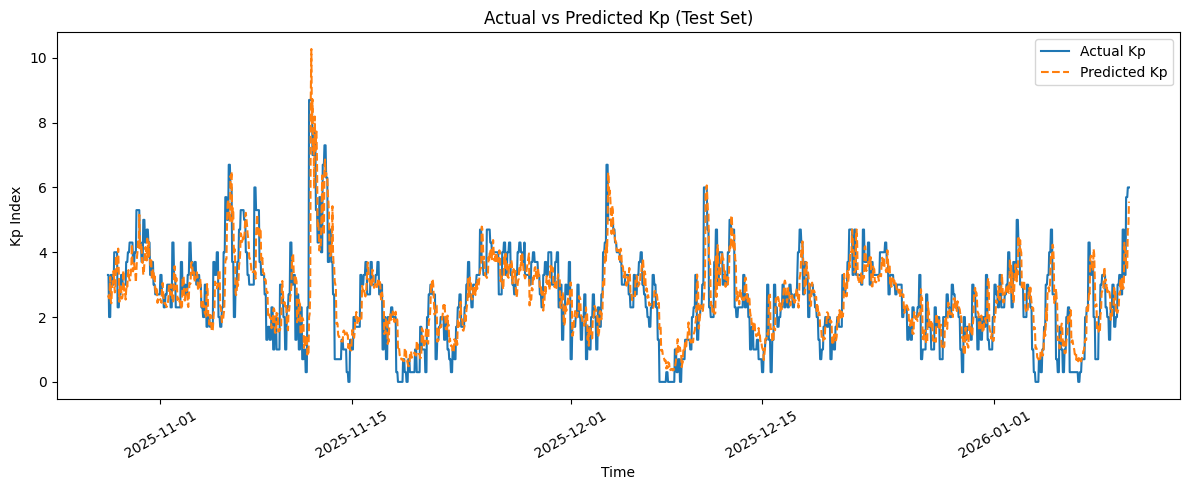

In [17]:
# ─────────────────────────────────────────────────────────
# STEP 7 — PLOT RESULTS
# ─────────────────────────────────────────────────────────

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(test_df["Timestamp"], y_test, label="Actual Kp")
plt.plot(test_df["Timestamp"], y_pred_test, label="Predicted Kp", linestyle="--")

plt.title("Actual vs Predicted Kp (Test Set)")
plt.xlabel("Time")
plt.ylabel("Kp Index")
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


In [18]:
# ─────────────────────────────────────────────────────────
# STEP 8 — SAVE MODEL
# ─────────────────────────────────────────

import joblib
import os

os.makedirs("models", exist_ok=True)
joblib.dump(model, "models/linear_regression/linear_regression_kp.pkl")

print("Model saved to models/linear_regression/linear_regression_kp.pkl")


Model saved to models/linear_regression/linear_regression_kp.pkl


In [22]:
# ─────────────────────────────────────────────────────────
# SAVE TEST PREDICTIONS
# ─────────────────────────────────────────────────────────

import os
import pandas as pd

# Create folder
os.makedirs("models/linear_regression", exist_ok=True)

# Create prediction dataframe
predictions_df = pd.DataFrame({
    "Timestamp": test_df["Timestamp"],
    "Actual_Kp": y_test,
    "Predicted_Kp": y_pred_test
})


In [21]:
train_predictions_df = pd.DataFrame({
    "Timestamp": train_df["Timestamp"],
    "Actual_Kp": y_train,
    "Predicted_Kp": y_pred_train
})

train_predictions_df.to_csv("models/linear_regression/train_predictions.csv", index=False)

print("Train predictions saved to models/linear_regression/train_predictions.csv")

Train predictions saved to models/linear_regression/train_predictions.csv
